# Loading legacy MEDUSA data

*medusa-kernel 2.0*

Years of MEDUSA recordings were saved with the **1.x** data model — files
such as `*.rec.bson`, `*.cvep.bson`, `*.mi.bson` and `*.rcp.bson` produced
by the MEDUSA Platform *Recorder* and paradigm apps. The 2.0 kernel keeps a
**read path** for them under `medusa.core.legacy`, so none of that data is
lost.

This tutorial shows how to:

- load a legacy recording with `medusa.core.legacy.recording.Recording`,
- inspect its biosignals and paradigm-specific experiment data,
- **bridge** the EEG into the modern `medusa.core.data` model
  (`ChannelSet` / `Signal` / `Recording`), so you can use the 2.0 signal,
  plotting and ML stack on old data.

> `medusa.core.legacy` is a **compatibility layer for reading old files**,
> not the API to build new recordings. For new work use
> `medusa.core.data` (see the *Recordings & streaming* tutorial).

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you're using Google Colab!
</div>

In [1]:
!pip install medusa-kernel

Import the modules used in this notebook.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import medusa_style
import medusa.plots as mp
from medusa.core.legacy.recording import Recording as LegacyRecording
from medusa.core.data import BidsInfo, Recording, Signal, ChannelSet
from medusa.signal.frequency_filtering import FIRFilter
from medusa.signal.spatial_filtering import car
from medusa.signal.segmentation import segment_signal
from medusa.signal.transforms import power_spectral_density
from medusa.signal.metrics.spectral import band_power

warnings.simplefilter("ignore")          # legacy loaders may emit notices
medusa_style.apply()
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('> imports OK')

> imports OK


## Where the example data lives

A handful of small legacy recordings ship with the medusa-kernel source,
under `docs/tutorials/data/legacy/`, grouped by paradigm:

| Folder        | Extension     | Paradigm                          |
|---------------|---------------|-----------------------------------|
| `rest_eeg/`   | `.rec.bson`   | Resting-state EEG                 |
| `cvep/`       | `.cvep.bson`  | c-VEP speller                     |
| `mi/`         | `.mi.bson`    | Motor imagery                     |
| `rcp_speller/`| `.rcp.bson`   | ERP (row-column P300) speller     |

If you cloned the repository they are already on disk; the cell below
resolves them relative to this notebook. To use your **own** legacy
recordings instead, just point `DATA` at the folder that holds them — the
bridge below works for any legacy `Recording`.

In [3]:
DATA = Path('data/legacy')
rest_path = DATA / 'rest_eeg' / 'S01.rec.bson'

if rest_path.exists():
    for sub in sorted(p.name for p in DATA.iterdir() if p.is_dir()):
        files = list((DATA / sub).glob('*.bson'))
        print(f'{sub:12s} {len(files)} file(s)  e.g. {files[0].name}')
else:
    print('Legacy example data not found next to this notebook.')
    print(f'Point DATA at your own legacy recordings (looked in: {DATA.resolve()}).')

cvep         8 file(s)  e.g. cvep_test1.cvep.bson
mi           8 file(s)  e.g. test_5.mi.bson
rcp_speller  5 file(s)  e.g. S1_TEST_1.rcp.bson
rest_eeg     1 file(s)  e.g. S01.rec.bson


## Load a legacy recording

`medusa.core.legacy.recording.Recording.load` reads the file and
reconstructs the 1.x object: a `Recording` holding one or more biosignals
(here an `EEG` object exposing `signal`, `fs` and `channel_set`), a
free-form `experiments` store, and acquisition metadata.

In [4]:
rec = LegacyRecording.load(str(rest_path))

eeg = rec.eeg                              # legacy EEG biosignal
legacy_labels = eeg.channel_set.l_cha      # 1.x channel set uses `l_cha`
print(f'> subject_id : {rec.subject_id!r}')
print(f'> biosignal  : EEG (accessed as rec.eeg)')
print(f'> EEG signal : {eeg.signal.shape} (samples, channels)')
print(f'> fs (Hz)    : {eeg.fs}')
print(f'> channels   : {legacy_labels}')

> subject_id : 'Session_8'
> biosignal  : EEG (accessed as rec.eeg)
> EEG signal : (77776, 16) (samples, channels)
> fs (Hz)    : 250.0
> channels   : ['FP1', 'FP2', 'F3', 'FZ', 'F4', 'T7', 'C3', 'CZ', 'C4', 'T8', 'P3', 'PZ', 'P4', 'F7', 'F8', 'POZ']


### Paradigm-specific experiment data

Beyond the raw biosignals, paradigm recordings carry an **experiment data**
object describing the task (stimulation matrix, command labels, trial
onsets, ...). It is reachable through `rec.experiments`. Each paradigm uses
its own class — `cvepspellerdata`, `midata`, `erpspellerdata` — but the EEG
bridges to 2.0 identically regardless of paradigm.

In [5]:
for sub, fname in [('cvep', 'cvep_train1.cvep.bson'),
                   ('mi', 'train_1.mi.bson'),
                   ('rcp_speller', 'S1_TRAIN_1.rcp.bson')]:
    path = DATA / sub / fname
    if not path.exists():
        continue
    r = LegacyRecording.load(str(path))
    print(f'{sub:12s} eeg={r.eeg.signal.shape} fs={r.eeg.fs}  '
          f'experiment data: {list(r.experiments)}')

cvep         eeg=(11600, 16) fs=256.0  experiment data: ['cvepspellerdata']


mi           eeg=(32640, 16) fs=256.0  experiment data: ['midata']


rcp_speller  eeg=(55152, 16) fs=256.0  experiment data: ['erpspellerdata']


## Bridge the EEG into the 2.0 model

The mapping from the legacy biosignal to `medusa.core.data` is direct:

| Legacy (1.x)                    | 2.0 (`medusa.core.data`)            |
|---------------------------------|-------------------------------------|
| `eeg.channel_set.l_cha`         | `ChannelSet.add_unipolar_eeg_channels(...)` |
| `eeg.signal`, `eeg.fs`          | `Signal(signal, fs, channel_set)`   |
| `recording.subject_id`          | `BidsInfo(subject=...)`              |

One catch: BIDS labels allow only letters and digits, while legacy
`subject_id`s are free-form (this one is `'Session_8'`). We sanitise it
before handing it to `BidsInfo`.

In [6]:
channel_set = ChannelSet().add_unipolar_eeg_channels(legacy_labels)
signal = Signal(eeg.signal.copy(), fs=eeg.fs, channel_set=channel_set)

subject = ''.join(c for c in str(rec.subject_id) if c.isalnum()) or '01'
rec2 = Recording(BidsInfo(subject=subject, task='rest', run=1))
rec2.add_signal('eeg', signal)

# Persist as a modern recording and confirm it round-trips losslessly
out_path = RESULTS / f'sub-{subject}_task-rest_run-1.h5'
rec2.save(str(out_path))
back = Recording.load(str(out_path))
lossless = np.allclose(back.signals['eeg'].signal, signal.signal)
print(f'> Bridged to a 2.0 Recording (subject {subject!r})')
print(f'> Saved {out_path.name} ({out_path.stat().st_size // 1024} KB), '
      f'lossless={lossless}')

> Bridged to a 2.0 Recording (subject 'Session8')
> Saved sub-Session8_task-rest_run-1.h5 (3564 KB), lossless=True


## Use the modern stack on the bridged data

The bridged `Signal` is an ordinary 2.0 object, so the whole signal /
plotting toolbox applies. As a sanity check we run the *local activation*
pipeline (band-pass → CAR → epoch → PSD → relative alpha power) and map the
alpha topography. Real resting EEG should show the expected **posterior
alpha** dominance.

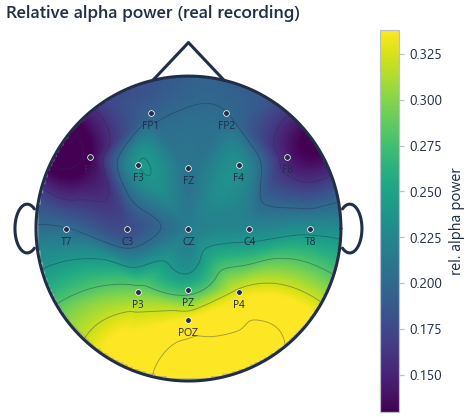

In [7]:
x = FIRFilter(order=1000, cutoff=(1, 40), btype='bandpass').fit_transform(
    signal.signal, signal.fs)
x = car(x)
epochs = segment_signal(x, segment_length=int(4 * signal.fs))
freqs, psd = power_spectral_density(epochs, signal.fs, segment=0.5,
                                    overlap=0.25, window='hamming')
alpha = band_power(psd, signal.fs, target_band=(8, 13), type='relative',
                   norm_range=(1, 40)).mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
mp.plot_topography(alpha, channel_set, ax, show_labels=True,
                   colorbar=True, cbar_label='rel. alpha power')
ax.set_title('Relative alpha power (real recording)')
mp.save_figure(fig, RESULTS / 'legacy_alpha_topography.png')
plt.show()

## Summary and next steps

In this tutorial you:

- loaded a legacy 1.x recording with
  `medusa.core.legacy.recording.Recording`,
- inspected its biosignals and paradigm-specific experiment data,
- bridged the EEG into the modern `medusa.core.data` model and saved it as a
  2.0 recording,
- ran a standard 2.0 analysis on the bridged data.

From here, the bridged `Signal` / epochs feed straight into the rest of the
tutorials:

- spectral and non-linear metrics (*Local activation analysis*),
- functional connectivity (*Functional connectivity analysis*),
- a deep-learning classifier (*Train a PyTorch classifier*).

See you in the next MEDUSA tutorial!